# Interactive script magic

In [63]:
_interactive = True  # Skip the next cell if you want to run in interactive (cell-by-cell) mode!

In [2]:
_interactive = False  # Automatically override _interactive to false if this notebook is run in batch mode!

# Basic principle of Planetary Radar:
Transmit short pulses at a given frequency for distance/c time
 * pulse duration should be ... pretty short (have to sum up many pulses to deal with noise)
 * pulse interval should be longer than the delay dispersion
 * or use coded long pulse waveform (pseudo-random)
 * Receive the echos, compute the response for each cell in a doppler delay grid (doppler varies across the limbs, delay varies with distance)

# Relevant papers
 * [Radar Echoes From the Moon](https://web.archive.org/web/20081029000712/http://www.eagle.ca/~harry/ba/eme/index.htm) -- historical
 * [Planetary Radar - State-of-the-Art Review](https://www.mdpi.com/2072-4292/15/23/5605) -- 2023 overview
 * [Planetary Radar Astronomy](https://nap.nationalacademies.org/read/21729/chapter/8) -- 2015 overview
 * [Planetary Radar](https://echo.jpl.nasa.gov/asteroids/ostro_1998_encyc_ss.pdf) -- 1998 overview
 * [Planetary Delay-Doppler Radar and the Long-Code Method](https://echo.jpl.nasa.gov/asteroids/harmon.2002.long.code.pdf) -- long-code method (recommends intercode -- coherent code sequence) for underspread Moon
 * [Earth-Based Radar Observations of Venus -- PDS Archive Description](https://pds-geosciences.wustl.edu/venus/arcb_nrao-v-rtls_gbt-3-delaydoppler-v1/vrm_90xx/document/venus_radar.pdf) -- Arecibo Venus data description

In [3]:
# To fetch the camras data, use something like:
#! wget -r --no-clobber --no-parent -R index.html?* https://data.camras.nl/thomas/sdr-eme/

In [4]:
# Install dependencies
#! pip install --quiet --upgrade astropy astroquery cupy-cuda12x ipympl jplephem matplotlib numpy scipy sigmf tqdm

In [5]:
import os
import pickle

import numpy as np
from matplotlib import pyplot as pl

from astropy import units as au
from astropy import constants as ak
from astropy import coordinates as ac
from astropy import time as at

import cupy

import scipy
import sigmf
from tqdm import tqdm

In [6]:
# Set high quality ephemerides -- may take a while to download!
# https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440_and_de441.pdf appears to recommend de440s for our purposes:
# - de440s : 1849 to 2150 (32 MB)
# - de440 : 1550 to 2650 (114 MB)
# - de441 : -13200 to 17191(3.2 GB)
ac.solar_system_ephemeris.set("de440s")
#ac.solar_system_ephemeris.set("jpl")

<ScienceState solar_system_ephemeris: 'de440s'>

# Constants

In [7]:
DWINGELOO_LAT = 52.81214958283062 * au.degree
DWINGELOO_LON = 6.396319071523311 * au.degree
DWINGELOO_HEIGHT = 70.26 * au.m

STOCKERT_LAT = 50.56944039751571 * au.degree
STOCKERT_LON = 6.721943350231514 * au.degree
STOCKERT_HEIGHT = 434.0 * au.m

tx_location = ac.EarthLocation(lat=DWINGELOO_LAT, lon=DWINGELOO_LON, height=DWINGELOO_HEIGHT, ellipsoid="WGS84")
rx_location = ac.EarthLocation(lat=STOCKERT_LAT, lon=STOCKERT_LON, height=STOCKERT_HEIGHT, ellipsoid="WGS84")

#MOON_RADIUS = 1_738_100.0 * au.m   # Equatorial radius
MOON_RADIUS = 1_737_400.0 * au.m   # Volumetric mean radius
#MOON_RADIUS = 17_000_000.0 * au.m   # HACK HACK HACK --> range needed to explain a ~0.03 Hz doppler error.

#TX_START = (1.000011 - 11.926e-6) * au.s  # From Thomas' notebook "Stockert, correct for H-maser offset Dwingeloo (1 MHz)"
TX_START = 1.0 * au.s

DATA_ROOT = 'data/'
DATA_PREFIX = f"{DATA_ROOT}sdr-eme/rx-2025-06-21/"

In [8]:
if 1: # Scan the available files, collect the metadata
    rx_info_map = {}
    for filename in os.listdir(DATA_PREFIX):
        if not filename.startswith('stockert'): continue
        if not filename.endswith('meta'): continue
        #if not 'chan0' in filename: continue
        sigmf_file = sigmf.sigmffile.fromfile(DATA_PREFIX + filename, skip_checksum=True)
        rx_info_map[filename] = sigmf_file.get_global_info()

In [9]:
if 0: # Run queries across the available files...
    for rx_filename, rx_info in rx_info_map.items():
        if not 'chan0' in rx_filename: continue
        desc = rx_info["core:description"]
        #if not '30sec' in desc: continue
        if not 'bpsk' in desc: continue
        print(rx_filename, rx_info["core:description"])

In [10]:
# Load the rx data
def loadRxTxFiles(rx_chan0_sigmf_filename):
    print(f"Loading RX file(s) {rx_chan0_sigmf_filename}")
    if 1: # Just use one polarity
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")
        ## Normalize the average power.
        #rx_samples /= np.mean(np.abs(rx_samples))
    
    if 0: # Combine both polarities:
        # Chan 0 is RHCP
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        # Chan 0 is LHCP
        rx_chan1_sigmf_filename = rx_chan0_sigmf_filename.replace("chan0", "chan1")
        rx_chan1_sigmf_file = sigmf.sigmffile.fromfile(rx_chan1_sigmf_filename)
        rx_chan0_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")
        rx_chan1_samples = rx_chan1_sigmf_file.read_samples().astype("complex64")
    
        ## Normalize the average channel power.
        #rx_chan0_samples /= np.mean(np.abs(rx_chan0_samples))
        #rx_chan1_samples /= np.mean(np.abs(rx_chan1_samples))
        
        # From Thomas' code: Combine RHCP at 80 degrees (cross-pol), LHCP at 260 (co-pol)
        rx_samples = rx_chan0_samples + np.exp(1j * 260 * np.pi / 180) * rx_chan1_samples
    
    rx_info = rx_chan0_sigmf_file.get_global_info()
    
    if 0:  # Debug: Basic rx file info
        display(rx_chan0_sigmf_file.get_global_info())
        display(rx_chan0_sigmf_file.get_captures())
        
    sample_rate = rx_info['core:sample_rate'] / au.s
    tx_filename = rx_info['core:description']
    captures = rx_chan0_sigmf_file.get_captures()
    frequency = captures[0]['core:frequency'] * au.Hz
    print(captures[0]['core:datetime'])
    rx_start_astrotime = at.Time(captures[0]['core:datetime'])
    print(rx_start_astrotime)

    # Load the tx waveform data
    if "2025-06-21" in rx_chan0_sigmf_filename:
        tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx-2025-06-21/{tx_filename}"
    else:
        tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx/{tx_filename}"
    print(f"  Loading TX file {tx_sigmf_filename}")
    tx_sigmf_file = sigmf.sigmffile.fromfile(tx_sigmf_filename)
    tx_samples = tx_sigmf_file.read_samples().astype("complex64")
    
    if 0:  # Debug: Basic tx file info
        tx_info = tx_sigmf_file.get_global_info()
        display(tx_info)
        display(len(tx_samples))

    return rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime

if _interactive:
    #rx_chan0_sigmf_filename = "sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta"
    #rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_35_05_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta"  # The 'overspread' images to left and right seem to be blurred in delay?
    #rx_chan0_sigmf_filename = "stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta"
    #rx_chan0_sigmf_filename = f"{DATA_PREFIX}/stockert_eme_2025_06_21_11_30_02_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta" # BPSK
    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(DATA_PREFIX + rx_chan0_sigmf_filename)

In [11]:
if 0: # Debug: rx spectrogram
    %matplotlib widget
    pl.figure()
    Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(rx_samples, Fs=sample_rate, NFFT=2**12, clim=[-110, -80])
    pl.title('RX Spectrogram')
    pl.gca().set_xlabel("Time (s)")
    pl.gca().set_ylabel("Frequency from center (Hz)")
    pl.gca().axvline(transmission_start, color="white", linestyle="--")
    pl.gca().axvline(transmission_start + expected_delay, color="white", linestyle="--")

In [12]:
if 0: # Debug: tx spectrogram
    nfft = nperseg = 2**8
    Sxx_tx, f_tx, t_tx, image_tx = pl.specgram(tx_samples, Fs=sample_rate, NFFT=nfft)
    pl.title('TX Spectrogram')
    pl.gca().set_xlabel("Time (s)")
    pl.gca().set_ylabel("Frequency from center (Hz)")

In [13]:
import math

def calculate_delta_point(lat1, lon1, lat2, lon2, delta_deg):
    """
    Calculate the point that is delta degrees away from point 1 in the direction of point 2.

    Args:
        lat1, lon1: Latitude and longitude of the starting point (in degrees)
        lat2, lon2: Latitude and longitude of the reference point (in degrees)
        delta_deg: distance in degrees

    Returns:
        tuple: (latitude, longitude) of the point
    """

    # Convert degrees to radians
    lat1_rad = lat1.to(au.rad).value
    lon1_rad = lon1.to(au.rad).value
    lat2_rad = lat2.to(au.rad).value
    lon2_rad = lon2.to(au.rad).value

    # Calculate the initial bearing from point 1 to point 2
    delta_lon = lon2_rad - lon1_rad

    y = math.sin(delta_lon) * math.cos(lat2_rad)
    x = (math.cos(lat1_rad) * math.sin(lat2_rad) -
         math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon))

    bearing = math.atan2(y, x)

    # Distance is 90 degrees (π/2 radians) on the unit sphere
    distance_rad = math.radians(delta_deg)

    # Calculate the destination point using the spherical law of cosines
    lat3_rad = math.asin(
        math.sin(lat1_rad) * math.cos(distance_rad) +
        math.cos(lat1_rad) * math.sin(distance_rad) * math.cos(bearing)
    )

    lon3_rad = lon1_rad + math.atan2(
        math.sin(bearing) * math.sin(distance_rad) * math.cos(lat1_rad),
        math.cos(distance_rad) - math.sin(lat1_rad) * math.sin(lat3_rad)
    )

    # Convert back to degrees
    lat3 = math.degrees(lat3_rad) * au.deg
    lon3 = math.degrees(lon3_rad) * au.deg

    # Normalize longitude to [-180, 180]
    #lon3 = ((lon3 + 180) % 360) - 180

    return lat3, lon3

if 0:
    # Test case: Start at (0°, 0°) and go towards (0°, 1°) - eastward direction
    lat1, lon1 = 0.0, 0.0  # Equator, Prime Meridian
    lat2, lon2 = 0.0, 1.0  # Slightly east

    result_lat, result_lon = calculate_point_90_degrees(lat1, lon1, lat2, lon2)
    print(f"Starting point: ({lat1}°, {lon1}°)")
    print(f"Reference point: ({lat2}°, {lon2}°)")
    print(f"Point 90° away: ({result_lat:.6f}°, {result_lon:.6f}°)")

    # Test case: Start at New York and go towards London direction
    ny_lat, ny_lon = 40.7128, -74.0060  # New York City
    london_lat, london_lon = 51.5074, -0.1278  # London

    result_lat, result_lon = calculate_point_90_degrees(ny_lat, ny_lon, london_lat, london_lon)
    print(f"Starting point: New York ({ny_lat}°, {ny_lon}°)")
    print(f"Reference point: London ({london_lat}°, {london_lon}°)")
    print(f"Point 90° away: ({result_lat:.6f}°, {result_lon:.6f}°)")

    # Verify the distance is approximately 90 degrees
    def haversine_distance(lat1, lon1, lat2, lon2):
        """Calculate great circle distance in degrees"""
        lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
        lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)

        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad

        a = (math.sin(dlat/2)**2 +
             math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2)
        c = 2 * math.asin(math.sqrt(a))

        return math.degrees(c)

    distance = haversine_distance(ny_lat, ny_lon, result_lat, result_lon)
    print(f"Verification: Distance from start to result = {distance:.6f}°")

In [14]:
# More complex doppler calculation, try to consider all the light travel times and the sub radar position on the surface of the moon.
def moonDopplerAndDelay_astropy(rx_time, tx_location, rx_location):
    # We'll use the doppler to correct the rx_samples, so all calculations are relative to rx_time.
    # We need three ICRS positions and velocities:
    #  - rx_location at rx_time
    #  - moon sub radar point at the time of a bounce that is received at rx_time
    #  - tx_location at the time of a transmission that bounces and then is received at rx_time
    rx_gcrs = rx_location.get_gcrs(rx_time)
    rx_icrs = rx_gcrs.transform_to(ac.ICRS())

    # Iterate to converge on the "bounce_time" of the apparent moon_surface, given the rx_location and rx_time.
    delta_light_travel_time = 20.0 * au.s
    bounce_time = rx_time
    approx_down_light_travel_time = 0.0 * au.s
    while np.any(np.fabs(delta_light_travel_time) > 1.0e-8 * au.s):
        moon_pos, moon_vel = ac.get_body_barycentric_posvel("moon", bounce_time)
        bc_down_dpos = moon_pos - rx_icrs.cartesian.without_differentials()
        bc_down_direction = bc_down_dpos / bc_down_dpos.norm()
        moon_surface_pos = moon_pos - MOON_RADIUS * bc_down_direction;
        distance = (moon_surface_pos - rx_icrs.cartesian.without_differentials()).norm()
        delta_light_travel_time = approx_down_light_travel_time - distance / ak.c
        approx_down_light_travel_time = distance / ak.c
        bounce_time = rx_time - approx_down_light_travel_time
    # Calculate moon_pos/vel once more with the best bounce_time    
    moon_pos, moon_vel = ac.get_body_barycentric_posvel("moon", bounce_time)
    bc_down_dpos = moon_pos - rx_icrs.cartesian.without_differentials()
    bc_down_direction = bc_down_dpos / bc_down_dpos.norm()
    # Find the moon surface sub-radar point (approximate because we're not using the lunar ellipsoid)
    moon_surface_pos = moon_pos - MOON_RADIUS * bc_down_direction;
    down_dpos = moon_surface_pos - rx_icrs.cartesian.without_differentials()
    down_range = down_dpos.norm()
    down_dvel = (moon_vel - rx_icrs.velocity)
    down_direction = down_dpos / down_range
    down_range_rate = np.dot(down_dvel.xyz.to(au.m / au.s).value, down_direction.xyz) * au.m / au.s

    print(down_dvel)
    down_ortho_rate = np.sqrt(sum(down_dvel.xyz.to(au.m/au.s).value**2) - down_range_rate.to(au.m/au.s).value**2) * au.m / au.s
    print(down_ortho_rate)

    # Iterate to converge on the "emitted_time" of the apparent tx_location, given the moon_surface_loc and bounce_time.
    delta_light_travel_time = 20.0 * au.s
    emitted_time = rx_time - approx_down_light_travel_time
    approx_up_light_travel_time = 0.0 * au.s
    while np.any(np.fabs(delta_light_travel_time) > 1.0e-8 * au.s):
        tx_gcrs = tx_location.get_gcrs(emitted_time)
        tx_icrs = tx_gcrs.transform_to(ac.ICRS())
        distance = (tx_icrs.cartesian.without_differentials() - moon_surface_pos).norm()
        delta_light_travel_time = approx_up_light_travel_time - distance / ak.c
        approx_up_light_travel_time = distance / ak.c
        emitted_time = rx_time - approx_down_light_travel_time - approx_up_light_travel_time
    # Calculate tx_icrs once more with the best emitted_time
    tx_gcrs = tx_location.get_gcrs(emitted_time)
    tx_icrs = tx_gcrs.transform_to(ac.ICRS())
    up_dpos = tx_icrs.cartesian.without_differentials() - moon_surface_pos
    up_range = up_dpos.norm()
    up_dvel = (tx_icrs.velocity - moon_vel)
    up_direction = up_dpos / up_range
    up_range_rate = np.dot(up_dvel.xyz.to(au.m / au.s).value, up_direction.xyz) * au.m / au.s

    doppler = frequency * (up_range_rate + down_range_rate) / ak.c
    delay = (up_range + down_range) / ak.c

    return doppler, delay

In [68]:
from astroquery.jplhorizons import Horizons
# See https://ssd.jpl.nasa.gov/horizons/manual.html#observer-table for details.

def moonDopplerAndDelay_horizons(frequency, rx_time, tx_location, rx_location):
    # Observe the moon center from rx_location at rx_time.
    down_moon_center = Horizons(id='301', location={'lon': DWINGELOO_LON, 'lat': DWINGELOO_LAT, 'elevation': DWINGELOO_HEIGHT}, epochs=rx_time.jd)
    down_moon_center_eph = down_moon_center.ephemerides()
    
    down_moon_center_range = down_moon_center_eph['delta'].to(au.m)[0]
    down_moon_center_range_rate = down_moon_center_eph['delta_rate'].to(au.m / au.s)[0]
    down_moon_center_light_travel_time = down_moon_center_eph['lighttime'].to(au.s)[0]  # Note: this isn't quite equal to range / c ?!?
    
    print("light times:", down_moon_center_eph['delta'].to(au.m) / ak.c, down_moon_center_eph['lighttime'].to(au.s)[0])

    # Get the sub radar point (SRP)
    bounce_lat = down_moon_center_eph['PDObsLat'].to(au.deg)[0]
    bounce_lon = down_moon_center_eph['PDObsLon'].to(au.deg)[0]

    # Also look up the SRP 1 second later.
    later_down_moon_center = Horizons(id='301', location={'lon': DWINGELOO_LON, 'lat': DWINGELOO_LAT, 'elevation': DWINGELOO_HEIGHT}, epochs=(rx_time + 0.1 * au.s).jd)
    later_down_moon_center_eph = down_moon_center.ephemerides()
    later_bounce_lat = later_down_moon_center_eph['PDObsLat'].to(au.deg)[0]
    later_bounce_lon = later_down_moon_center_eph['PDObsLon'].to(au.deg)[0]
    
    # Use the two SRPs to calculate the limb points
    pos_limb_lat, pos_limb_lon = calculate_delta_point(bounce_lat, bounce_lon, later_bounce_lat, later_bounce_lon, 90.0)
    # neg limb point is on the other side of the moon...
    neg_limb_lat = -pos_limb_lat
    neg_limb_lon = pos_limb_lon - 180.0 * au.deg
    print(pos_limb_lat, pos_limb_lon)
    
    # And query the apparent range rate of the limb points
    down_moon_pos_limb = Horizons(id={'body':'301', 'lon': pos_limb_lon, 'lat': pos_limb_lat, 'elevation': 0 * au.m}, location={'lon': DWINGELOO_LON, 'lat': DWINGELOO_LAT, 'elevation': DWINGELOO_HEIGHT}, epochs=rx_time.jd)
    down_moon_pos_limb_eph = down_moon_pos_limb.ephemerides()
    down_moon_pos_limb_range_rate = down_moon_pos_limb_eph['delta_rate'].to(au.m / au.s)[0]
    #print(f"{down_moon_pos_limb_range_rate=}")
    #print(f"{down_moon_pos_limb_range_rate - down_moon_center_range_rate=}")
    down_moon_neg_limb = Horizons(id={'body':'301', 'lon': neg_limb_lon, 'lat': neg_limb_lat, 'elevation': 0 * au.m}, location={'lon': DWINGELOO_LON, 'lat': DWINGELOO_LAT, 'elevation': DWINGELOO_HEIGHT}, epochs=rx_time.jd)
    down_moon_neg_limb_eph = down_moon_neg_limb.ephemerides()
    down_moon_neg_limb_range_rate = down_moon_neg_limb_eph['delta_rate'].to(au.m / au.s)[0]
    #print(f"{down_moon_neg_limb_range_rate=}")
    #print(f"{down_moon_neg_limb_range_rate - down_moon_center_range_rate=}")

    # Refine the down leg by querying the apparent sub radar point (from down_moon_center).
    down_moon_srp = Horizons(id={'body':'301', 'lon': bounce_lon, 'lat': bounce_lat, 'elevation': 0 * au.m}, location={'lon': DWINGELOO_LON, 'lat': DWINGELOO_LAT, 'elevation': DWINGELOO_HEIGHT}, epochs=rx_time.jd)
    down_moon_srp_eph = down_moon_srp.ephemerides()
    down_moon_srp_range = down_moon_srp_eph['delta'].to(au.m)[0]
    down_moon_srp_range_rate = down_moon_srp_eph['delta_rate'].to(au.m / au.s)[0]
    down_moon_srp_light_travel_time = down_moon_srp_eph['lighttime'].to(au.s)[0]  # Note: this isn't quite equal to range / c ?!?
    srp_bounce_time = rx_time - down_moon_srp_light_travel_time
    
    # Observing the tx_location from the moon sub radar point at bounce time
    srp_up = Horizons(id={'lon': STOCKERT_LON, 'lat': STOCKERT_LAT, 'elevation': STOCKERT_HEIGHT}, location={'body':'301', 'lon': bounce_lon, 'lat': bounce_lat, 'elevation': 0 * au.m}, epochs=srp_bounce_time.jd)
    srp_up_eph = srp_up.ephemerides()
    srp_up_range = srp_up_eph['delta'].to(au.m)[0]
    srp_up_range_rate = srp_up_eph['delta_rate'].to(au.m / au.s)[0]
    
    doppler = frequency * (srp_up_range_rate + down_moon_srp_range_rate) / ak.c
    delay = (srp_up_range + down_moon_srp_range) / ak.c

    down_moon_pos_limb_light_travel_time = down_moon_pos_limb_eph['lighttime'].to(au.s)[0]  # Note: this isn't quite equal to range / c ?!?
    pos_limb_bounce_time = rx_time - down_moon_pos_limb_light_travel_time
    down_moon_neg_limb_light_travel_time = down_moon_neg_limb_eph['lighttime'].to(au.s)[0]  # Note: this isn't quite equal to range / c ?!?
    neg_limb_bounce_time = rx_time - down_moon_neg_limb_light_travel_time
    
    pos_limb_up = Horizons(id={'lon': STOCKERT_LON, 'lat': STOCKERT_LAT, 'elevation': STOCKERT_HEIGHT}, location={'body':'301', 'lon': pos_limb_lon, 'lat': pos_limb_lat, 'elevation': 0 * au.m}, epochs=pos_limb_bounce_time.jd)
    pos_limb_up_eph = pos_limb_up.ephemerides()
    pos_limb_up_range = pos_limb_up_eph['delta'].to(au.m)[0]
    pos_limb_up_range_rate = pos_limb_up_eph['delta_rate'].to(au.m / au.s)[0]
    
    neg_limb_up = Horizons(id={'lon': STOCKERT_LON, 'lat': STOCKERT_LAT, 'elevation': STOCKERT_HEIGHT}, location={'body':'301', 'lon': neg_limb_lon, 'lat': neg_limb_lat, 'elevation': 0 * au.m}, epochs=neg_limb_bounce_time.jd)
    neg_limb_up_eph = neg_limb_up.ephemerides()
    neg_limb_up_range = neg_limb_up_eph['delta'].to(au.m)[0]
    neg_limb_up_range_rate = neg_limb_up_eph['delta_rate'].to(au.m / au.s)[0]
    
    pos_limb_doppler_delta = frequency * (pos_limb_up_range_rate + down_moon_pos_limb_range_rate) / ak.c - doppler
    neg_limb_doppler_delta = frequency * (neg_limb_up_range_rate + down_moon_neg_limb_range_rate) / ak.c - doppler
    #print('+90 limb doppler delta', pos_limb_doppler_delta)
    #print('-90 limb doppler delta', neg_limb_doppler_delta)
    min_doppler_delta = min(pos_limb_doppler_delta, neg_limb_doppler_delta)
    max_doppler_delta = max(pos_limb_doppler_delta, neg_limb_doppler_delta)
    return doppler, delay, min_doppler_delta, max_doppler_delta

In [105]:
! mkdir --parents spicey_kernels
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440s.bsp
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de442s.bsp
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00011.tpc
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/moon_pa_de440_200625.bpc
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf
! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf

File ‘naif0012.tls’ already there; not retrieving.

File ‘de440s.bsp’ already there; not retrieving.

File ‘earth_latest_high_prec.bpc’ already there; not retrieving.

File ‘pck00011.tpc’ already there; not retrieving.

File ‘moon_pa_de440_200625.bpc’ already there; not retrieving.

File ‘moon_de440_250416.tf’ already there; not retrieving.

File ‘moon_de440_250416.tf’ already there; not retrieving.

--2025-07-05 10:56:33--  https://naif.jpl.nasa.gov/pub/naif/utilities/PC_Linux_64bit/pinpoint
Resolving naif.jpl.nasa.gov (naif.jpl.nasa.gov)... 137.79.133.14
Connecting to naif.jpl.nasa.gov (naif.jpl.nasa.gov)|137.79.133.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4267120 (4.1M)
Saving to: ‘pinpoint’

pinpoint            100%[===================>]   4.07M  1.13MB/s    in 3.9s    

2025-07-05 10:56:38 (1.05 MB/s) - ‘pinpoint’ saved [4267120/4267120]



In [108]:
# Generate SPICE kernels for the RX and TX sites, so they can be referenced.
#! wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/utilities/PC_Linux_64bit/pinpoint
#! chmod u+x pinpoint
! ./pinpoint -def observatories.defs -pck spicey_kernels/pck00011.tpc -spk spicey_kernels/observatories.bsp -fk spicey_kernels/observatories.tf

In [109]:
import spiceypy as sp
sp.tkvrsn('TOOLKIT')
SPICEY_KERNEL_DIR = "spicey_kernels"

sp.furnsh(f"{SPICEY_KERNEL_DIR}/naif0012.tls")                # For timestamp conversions
sp.furnsh(f"{SPICEY_KERNEL_DIR}/de440s.bsp")                  # For Earth and Moon positions (use 440 for compatibility with Moon orientation below)
sp.furnsh(f"{SPICEY_KERNEL_DIR}/pck00011.tpc")                # For Earth and Moon size and shape
sp.furnsh(f"{SPICEY_KERNEL_DIR}/earth_latest_high_prec.bpc")  # For best Earth orientation
sp.furnsh(f"{SPICEY_KERNEL_DIR}/moon_pa_de440_200625.bpc")    # For best Moon orientation (needs moon_de440_220930.tf)
sp.furnsh(f"{SPICEY_KERNEL_DIR}/moon_de440_250416.tf")        # For best Moon orientation
sp.furnsh(f"{SPICEY_KERNEL_DIR}/observatories.bsp")           # For observatory positions
sp.furnsh(f"{SPICEY_KERNEL_DIR}/observatories.tf")            # For observatory frames

# For guidance on high-accuracy kernels for Earth and Moon, see
# https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/Tutorials/pdf/individual_docs/23_lunar-earth_pck-fk.pdf
# For Earth, use ITRF93 frame
# For Moon, use MOON_ME frame

In [110]:
# Convert from UTC to TDB seconds past the J2000 epoch.
sp_rx_start_time = sp.str2et(rx_start_astrotime.utc.value)
#[dim, radii] = spiceypy.bodvrd("EARTH", "RADII", 3)
#tx_georec = spiceypy.georec(DWINGELOO_LON, DWINGELOO_LAT, DWINGELOO_HEIGHT, radii[0], flattening)

posvel, lt = sp.spkezr("MOON", sp_rx_start_time, 'J2000', 'CN', "STOCKERT")
posvel, lt = sp.spkezr("MOON", sp_rx_start_time, 'J2000', 'CN', "STOCKERT")
#pos, vel = sp.spkezr(target, t_rx, 'J2000', 'CN', receiver)
print(posvel, lt)

[ 2.96916460e+05  1.80618974e+05  9.92133278e+04 -3.48441835e-01
  7.39773795e-01  4.01727240e-01] 1.2055741183942665


In [69]:
if _interactive: # Calculate predicted doppler center frequency
    #doppler_start, delay_start = moonDopplerAndDelay_astropy(rx_start_astrotime, tx_location, rx_location)
    doppler_start, delay_start, min_doppler_delta_start, max_doppler_delta_start = moonDopplerAndDelay_horizons(frequency, rx_start_astrotime, tx_location, rx_location)
    print(f"{doppler_start=} {delay_start=}")
#    
#    rx_duration = len(rx_samples) / sample_rate
#    rx_end_astrotime = rx_start_astrotime + rx_duration
#    
#    #doppler_end, delay_end = moonDopplerAndDelay_astropy(rx_end_astrotime, tx_location, rx_location)
#    doppler_end, delay_end = moonDopplerAndDelay_horizons(rx_end_astrotime, tx_location, rx_location)
#    print(f"{doppler_end=} {delay_end=}")
#    
#    # Simple doppler_rate model, linear from start to end. Generally good enough for 30s windows?
#    doppler_rate = (doppler_end - doppler_start) / rx_duration
#    print(f"{doppler_rate=}")

light times: [1.20573866] s 1.2057384 s
85.96940199999996 deg 356.97953900000005 deg
doppler_start=<Quantity 1627.58190468 Hz> delay_start=<Quantity 2.39991393 s>


In [34]:
def calculateDelayWindowIndices(sample_rate, delay_start, len_rx_samples, len_tx_samples):
    moon_delay_depth = MOON_RADIUS / ak.c * 2  # round-trip delay depth
    t_start = TX_START + delay_start - 0.001 * au.s
    t_end = TX_START + delay_start + moon_delay_depth + 0.001 * au.s
    
    cor_lags = scipy.signal.correlation_lags(len_rx_samples, len_tx_samples, mode="valid") / sample_rate
    cor_i_start = np.argwhere(cor_lags > t_start)[0][0]
    cor_i_end = np.argwhere(cor_lags > t_end)[0][0]
    
    return cor_lags, cor_i_start, cor_i_end

#if _interactive:  # Calculate the delay window of interest
if 1:  # Calculate the delay window of interest
    cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, delay_start, len(rx_samples), len(tx_samples))

3.3913595396547707 s 3.4049502248347157 s
-24.0 s 0.0 s


IndexError: index 0 is out of bounds for axis 0 with size 0

In [18]:
if 0:  # HACK: manually override doppler delay parameters
    print("HACK HACK HACK")
    
    # These are from Thomas' notebook.
    # FOR: rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chanXXX.sigmf-meta
    # ... but they're not perfect (see peak correlation and image symmetry checks)
    #doppler_start = -1046.669 * au.Hz
    #doppler_rate = 0.13120475496564593 * au.Hz / au.s 
    #delay_start = 2.592436 * au.s 

    ## MANUAL BEST FIT (first doppler_start using delay-doppler image left-right symmetry), then delay_start using the correlation spike.
    # FOR: rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chanXXX.sigmf-meta
    doppler_start = -1046.605 * au.Hz
    doppler_rate = 0.13120475496564593 * au.Hz / au.s 
    delay_start = 2.59245 * au.s

    #doppler_start = -1049.6950 * au.Hz # FROM SCAN?!?
    doppler_rate = 0.1310 * au.Hz / au.s 
    
    print(f"{doppler_start=}")
    print(f"{delay_start=}")
    print(f"{doppler_rate=}")

In [19]:
if 0: # Search for best doppler using peak correlation strength
    # If the current hypothesis is that the empirical doppler error is primarily caused by tx and rx frequency errors,
    # then we are searching for the sum of the frequency errors. If these errors don't change much over the course
    # of an observation (a big 'if'), then I think we can assume the doppler_rate is pretty good, don't have to search over it.
    
    # Do everything in GPU memory, if it fits!
    cupy_f_shifts = np.linspace(doppler_start.to(au.Hz).value - 0.2, doppler_start.to(au.Hz).value + 0.2, 1000)
    cupy_tx_samples = cupy.asarray(tx_samples, dtype=cupy.complex64)
    cupy_rx_samples = cupy.asarray(rx_samples, dtype=cupy.complex64)
    best_peak_doppler = doppler_start
    best_peak = 0.0
    
    # Cache computations/allocations outside the for loop.
    cupy_conj_fft_tx_samples = cupy.conj(cupy.fft.fft(cupy.pad(cupy_tx_samples, (0, len(rx_samples) - len(tx_samples)))))
    #cupy_rx_range = -1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(rx_samples))
    cupy_rx_t_s = cupy.arange(len(rx_samples)) / sample_rate.value
    
    #for i in tqdm(range(len(cupy_f_shifts))):
    for i in range(len(cupy_f_shifts)):
        #cupy_rx_samples_shifted = cupy_rx_samples * cupy.exp(cupy_f_shifts[i] * cupy_rx_range)
        cupy_rx_samples_shifted = cupy_rx_samples * cupy.exp(-1j * 2 * np.pi * (-cupy_f_shifts[i] * cupy_rx_t_s + (-doppler_rate.value * cupy_rx_t_s**2) / 2)).T
        #cupy_rx_samples_shifted = cupy_rx_samples * cupy.exp(-1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(rx_samples))
        cupy_cor_shifted = cupy.fft.ifft(cupy.fft.fft(cupy_rx_samples_shifted) * cupy_conj_fft_tx_samples)
        #cor_max = cupy.max(cupy.abs(cupy_cor_shifted))
        #cor_max = cupy.max(cupy.abs(cupy_cor_shifted[cor_i_start:(cor_i_start+2000)]))
        cor_max = cupy.max(cupy.abs(cupy_cor_shifted[cor_i_start:cor_i_end]))
        if cor_max > best_peak:
            best_peak = cor_max
            best_peak_doppler = cupy_f_shifts[i]
            #print(i, best_peak, best_peak_doppler)

    print(f"{best_peak_doppler=}")
    print(f"Calculated vs search doppler delta: {doppler_start - best_peak_doppler * au.Hz}")

    doppler_start = best_peak_doppler * au.Hz

    if 1: # Debug
        phi_Hz = (-best_peak_doppler * cupy_rx_t_s) + (-doppler_rate.value * cupy_rx_t_s**2) / 2
        cupy_rx_samples_shifted = cupy_rx_samples * cupy.exp(-1j * 2 * np.pi * phi_Hz).T
        cupy_cor_shifted = cupy.fft.ifft(cupy.fft.fft(cupy_rx_samples_shifted) * cupy_conj_fft_tx_samples)
        pl.figure()
        pl.title("RX-compensated/TX correlation (delay window)")
        pl.plot(cor_lags[cor_i_start:cor_i_end] / sample_rate, cupy.abs(cupy_cor_shifted[cor_i_start:cor_i_end]).get(), label="signal")
        pl.gca().axvline(TX_START.value + delay_start.value, linestyle="--", color="grey", label="expected based on Moon distance",)
        #pl.plot(cupy.abs(cupy_cor_shifted[cor_i_start:(cor_i_start+2000)]).get())
        rx_samples_compensated = cupy_rx_samples_shifted.get()

In [20]:
if 0: # Compensate for time-varying doppler (sum of dopplers from transmitter -> moon, and moon -> receiver)
    # Slow on CPU, but just doing it once...
    t_s = np.arange(len(rx_samples)) / sample_rate
    phi_Hz = (-doppler_start * t_s) + (-doppler_rate * t_s**2) / 2  # Instantaneous phase.
    rx_samples_compensated = rx_samples * np.exp(-1j * 2 * np.pi * phi_Hz.value).T

In [21]:
if 0: # Debug: compensated rx spectrogram
    %matplotlib widget
    pl.figure()
    nfft = nperseg = 2**8
    Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(rx_samples_compensated, Fs=sample_rate, NFFT=nfft, clim=[-110, -80])
    pl.grid()

In [22]:
if 0:  # Debug: check tx signal autocorrelation
    cor = scipy.signal.correlate(tx_samples, tx_samples, mode="full")
    cor_lags = scipy.signal.correlation_lags(len(tx_samples), len(tx_samples), mode="full") / sample_rate
    pl.figure()
    pl.plot(cor_lags, np.abs(cor), label="signal")
    pl.title("TX auto-correlation")
    #pl.title("Zadoff Chu auto-correlation")
    #pl.title("BPSK auto-correlation")

In [23]:
if 0:  # Debug: check calculated delay and doppler by looking at the correlation of the rx_compensated and tx signals.
    #%matplotlib widget
    # Slow on CPU, but just doing it once...
    #cor = scipy.signal.correlate(rx_samples_compensated, tx_samples, mode="valid")
    cor = scipy.signal.correlate(rx_samples, tx_samples, mode="valid")
    cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples), mode="valid") / sample_rate
    pl.subplot(211)
    pl.title("RX-compensated/TX correlation (full)")
    pl.plot(cor_lags, np.abs(cor), label="signal")
    pl.gca().axvline(TX_START.value + delay_start.value, linestyle="--", color="grey", label="expected based on Moon distance",)
    pl.legend()
    pl.subplot(212)
    pl.title("RX-compensated/TX correlation (delay window)")
    #pl.plot(cor_lags, np.abs(cor), label="signal")
    #pl.gca().set_xlim([TX_START.value + delay_start.value - 0.001, TX_START.value + delay_start.value + 0.001])
    pl.plot(cor_lags[cor_i_start:cor_i_end], np.abs(cor[cor_i_start:cor_i_end]), label="signal")
    pl.gca().axvline(TX_START.value + delay_start.value, linestyle="--", color="grey", label="expected based on Moon distance",)

In [24]:
# CUDA implementation: about 50 it/s on an nvidia rtx 3080
def correlateSignalCUDA(tx_samples, rx_samples, cor_i_start, cor_i_end, f_shifts):
    # Do everything in GPU memory, if it fits!
    tx_samples = cupy.asarray(tx_samples, dtype=cupy.complex64)
    rx_samples = cupy.asarray(rx_samples, dtype=cupy.complex64)
    A = cupy.asarray(np.zeros((len(f_shifts), cor_i_end - cor_i_start)))
    # Cache computations/allocations outside the for loop.
    fft_rx_samples = cupy.fft.fft(rx_samples)
    tx_samples_shifted = cupy.zeros_like(rx_samples)
    tx_range = -1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(tx_samples)) 
    for i in tqdm(range(len(f_shifts))):
        tx_samples_shifted[:len(tx_samples)] = tx_samples * cupy.exp(f_shifts[i] * tx_range)
        cor_shifted = cupy.fft.ifft(fft_rx_samples * cupy.conj(cupy.fft.fft(tx_samples_shifted)))
        A[i] = cupy.abs(cor_shifted[cor_i_start:cor_i_end])
    # Single copy back to CPU at the end.
    return cupy.asnumpy(A)

In [25]:
if _interactive: # NOTE: hard-code doppler frequency shifts
    #f_shifts = np.linspace(-15, 15, 3000)
    f_shifts = np.linspace(-5, 5, 3000) + doppler_start.to(au.Hz).value
    
    A = correlateSignalCUDA(tx_samples, rx_samples_compensated, cor_i_start, cor_i_end, f_shifts) # >100x faster than reference
    log_A = np.log(A)

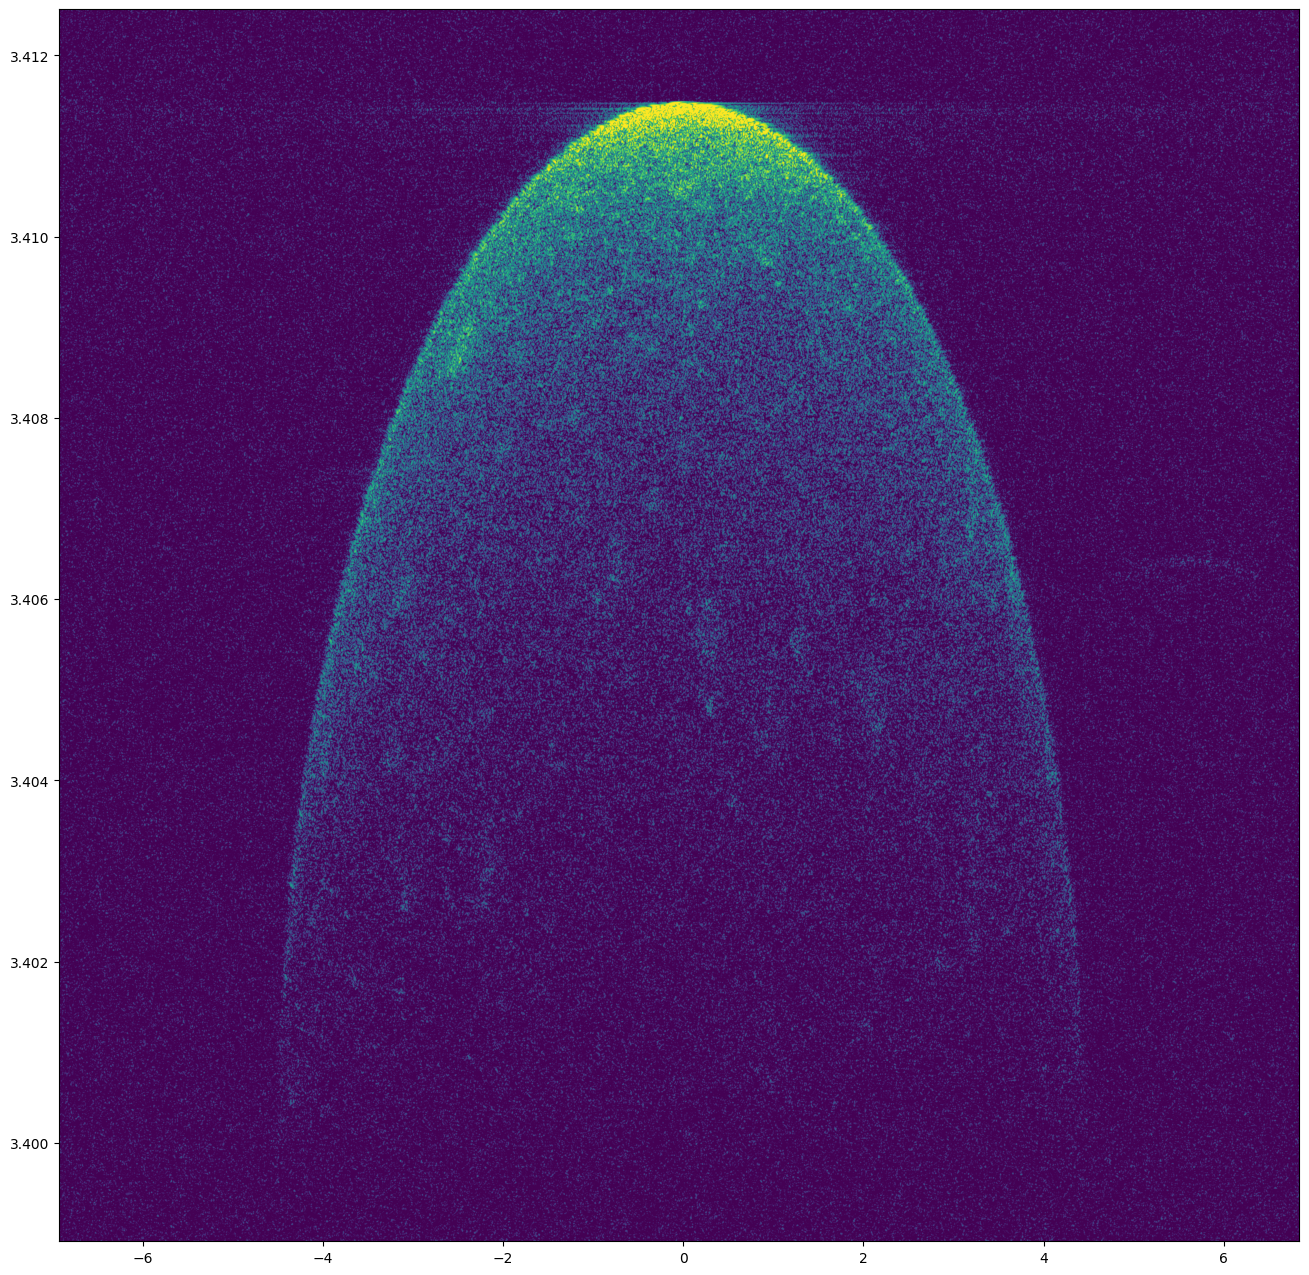

In [62]:
if 1: # Show the initial doppler-delay image
    pl.figure(figsize=(16,16))
    pl.imshow(log_A.T, 
              extent=[
                  f_shifts[0],
                  f_shifts[-1],
                  cor_lags[cor_i_start].value,
                  cor_lags[cor_i_end].value,
              ],
              aspect='auto',
              vmin=log_A.max() * 0.4,
              vmax=log_A.max() * 0.8, 
             )

In [27]:
if 0: # Debug the central doppler frequency by flipping horizontally and summing.
    #%matplotlib widget
    pl.figure(figsize=(16,16))
    pl.imshow(log_A.T + log_A.T[:, ::-1], aspect='auto')  
    pl.gca().axvline(log_A.shape[0] / 2.0, linestyle="--",color="grey")

In [28]:
def coarseTuneRoll(img, filename=None): # Coarse-tune the doppler centering by rolling to maximize left-right symmetry
    best_col_offset = 0
    best_col_offset_sum = 0
    #img_h = img.T  # Whole image
    # Extract a slice that corresponds to the limb being in position for img_mirror below.
    #img_h = img[:, 3000:3200].copy().T  # For 1 MHz data
    img_h = img[:, 1400:1600].copy().T  # For 250 kHz data
    #pl.imshow(img_h)
    offset_range = range(-200, 201)  # Depends on how confident we are in the doppler prediction!
    for offset in offset_range:
        img_tmp = np.roll(img_h, offset)
        img_mirror = img_tmp[:, 400:600] * np.fliplr(img_tmp[:, -600:-400])
        #img_mirror = img_tmp * np.fliplr(img_tmp)  # Whole row!
        #pl.figure(figsize=(2, 3))
        #pl.imshow(img_mirror)
        #pl.title('' + str(offset))
        total_sum = np.sum(img_mirror)
        #print(offset, total_sum)
        if total_sum > best_col_offset_sum:
            best_col_offset_sum = total_sum
            best_col_offset = offset
    return best_col_offset

In [29]:
if 0: # Pixel-level search for central doppler frequency that leads to symmetric lobes.
#    best_col_offset = coarseTuneRoll(log_A)
#    print(f"{best_col_offset=}")
#    print(f"(one column frequency offset is {abs(f_shifts[0] - f_shifts[1])})")
#    best_freq_offset = f_shifts[int(f_shifts.shape[0] / 2) - best_col_offset] * au.Hz
#    print(f"{best_freq_offset=}")
#    best_col_doppler = doppler_start + best_freq_offset
#    print(f"{best_col_doppler=}")
#    
#    log_A_rolled = np.roll(log_A.T, best_col_offset).T
    
    if 0:  # Debug
        pl.figure(figsize=(16,16))
        pl.imshow(log_A_rolled.T + log_A_rolled.T[:, ::-1], aspect='auto')  
        pl.gca().axvline(log_A.shape[0] / 2.0, linestyle="--",color="grey")

    if 1:  # Result
        #pl.figure(figsize=(16,16))
        #pl.imshow(log_A_rolled.T, aspect='auto', vmax=log_A_rolled.max() * 0.8, vmin=log_A.max() * 0.4)
        #pl.gca().axvline(log_A.shape[0] / 2.0, linestyle="--",color="grey")
        pl.imsave(rx_chan0_sigmf_filename + "_log_A_rolled.png", log_A_rolled.T, vmax=log_A_rolled.max() * 0.8, vmin=log_A_rolled.max() * 0.4) 

In [52]:
# BATCH MODE
assert(not _interactive) 
for rx_filename, rx_info in rx_info_map.items():
    if not 'chan0' in rx_filename: continue
    desc = rx_info["core:description"]
    #if not '30sec' in desc: continue
    if not 'zadoff-chu' in desc: continue
    #if not 'bpsk' in desc: continue

    if rx_filename != "stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta": continue
    #if rx_filename != "stockert_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta": continue
    print(rx_filename, rx_info["core:description"])
    
    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(DATA_PREFIX + rx_filename)
    
    doppler_start, delay_start, min_doppler_delta_start, max_doppler_delta_start = moonDopplerAndDelay_horizons(frequency, rx_start_astrotime, tx_location, rx_location)
    print(f"{doppler_start=} {delay_start=}")
    
    rx_duration = len(rx_samples) / sample_rate
    rx_end_astrotime = rx_start_astrotime + rx_duration
    
    doppler_end, delay_end, min_doppler_delta_end, max_doppler_delta_end = moonDopplerAndDelay_horizons(frequency, rx_end_astrotime, tx_location, rx_location)
    print(f"{doppler_end=} {delay_end=}")
    
    # Simple doppler_rate model, linear from start to end. Generally good enough for 30s windows?
    doppler_rate = (doppler_end - doppler_start) / rx_duration
    print(f"{doppler_rate=}")

    # Adjust the rx_samples for the time-varying doppler 
    t_s = np.arange(len(rx_samples)) / sample_rate
    phi_Hz = (-doppler_start * t_s) + (-doppler_rate * t_s**2) / 2
    rx_samples_compensated = rx_samples * np.exp(-1j * 2 * np.pi * phi_Hz.value).T

    min_delay = min(delay_start, delay_end)
    min_doppler_delta = min(min_doppler_delta_start, min_doppler_delta_end)
    max_doppler_delta = max(max_doppler_delta_start, max_doppler_delta_end)
    print(min_doppler_delta, max_doppler_delta)

    cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, min_delay, len(rx_samples), len(tx_samples))

    f_shifts = np.linspace(min_doppler_delta.to(au.Hz).value, max_doppler_delta.to(au.Hz).value, 3000)
    A = correlateSignalCUDA(tx_samples, rx_samples_compensated, cor_i_start, cor_i_end, f_shifts)
    log_A = np.log(A)
    pl.imsave(rx_filename + "_log_A.png", log_A.T, vmax=log_A.max() * 0.8, vmin=log_A.max() * 0.4) 
    break
    

stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x.sigmf-meta
Loading RX file(s) data/sdr-eme/rx-2025-06-21/stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta
2025-06-21T11:18:31.000145
2025-06-21T11:18:31.000
  Loading TX file data//sdr-eme/tx-2025-06-21/zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x.sigmf-meta
85.96940199999996 deg 356.97953900000005 deg
doppler_start=<Quantity 1627.58190468 Hz> delay_start=<Quantity 2.39991393 s>
85.96853600000001 deg 356.978858 deg
doppler_end=<Quantity 1633.83335914 Hz> delay_end=<Quantity 2.39999675 s>
doppler_rate=<Quantity 0.09471901 Hz / s>
-3.4629642017212063 Hz 3.419184081008325 Hz
3.398913930152875 s 3.41250461533282 s
0.0 s 6.0 s
849729 853127
3398


100%|███████████████████████████████████████| 3000/3000 [00:30<00:00, 99.33it/s]


-3.4629642017212063 Hz 3.419184081008325 Hz


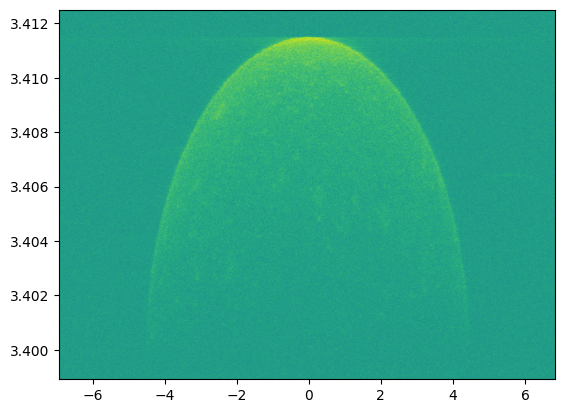

In [60]:
print(min_doppler_delta, max_doppler_delta)
pl.imshow(log_A.T, 
          extent=[
              f_shifts[0],
              f_shifts[-1],
              cor_lags[cor_i_start].value,
              cor_lags[cor_i_end].value,
          ],
          aspect='auto',
         )

# Appendix

In [ ]:
# Note: we calculate the doppler at the start and end of rx, not tx, because we will use it to
# correct rx_samples.
# There are a lot of different ways to compute this: astropy, jplHorizons, poliastro, spicey.

## SIMPLE
#def moonDopplerAndDelay_astropy(rx_time, tx_location, rx_location):
#    approx_moon_gcrs = ac.get_body("moon", rx_time, location=tx_location)
#    approx_light_travel_time = (approx_moon_gcrs.distance - MOON_RADIUS) / ak.c
#    
#    # Transmit "up" from Dwingeloo to the moon.
#    # NOTE: get_body returns the apparent position of the object at the observer's time and location,
#    # so for "up", we really want the earth-observed-from-moon direction, but we can only get moon-observed-from-earth.
#    # Since astropy get_body doesn't give radial velocity directly, we simply take the derivative of the range!
#    dt = 0.1 * au.s
#    up_moon_gcrs_1 = ac.get_body("moon", rx_time - approx_light_travel_time - dt, location=tx_location)
#    up_moon_gcrs_2 = ac.get_body("moon", rx_time - approx_light_travel_time + dt, location=tx_location)
#    up_radial_velocity = ((up_moon_gcrs_2.distance - up_moon_gcrs_1.distance) / (2 * dt)).to(au.m / au.s)
#    
#    # Receive "down" from the moon to Stockert. Note: we actually get the "up" path, just with a slight delay.
#    down_moon_gcrs_1 = ac.get_body("moon", rx_time - dt, location=rx_location)
#    down_moon_gcrs_2 = ac.get_body("moon", rx_time + dt, location=rx_location)
#    down_radial_velocity = ((down_moon_gcrs_2.distance - down_moon_gcrs_1.distance) / (2 * dt)).to(au.m / au.s)
#    
#    delay = (up_moon_gcrs_1.distance + down_moon_gcrs_2.distance - 2 * MOON_RADIUS) / ak.c
#    doppler = frequency * (up_radial_velocity + down_radial_velocity) / ak.c
#    return doppler, delay.to(au.s)

In [ ]:
#import spicepy
#spiceypy.furnsh(f"~/.astropy//naif0012.tls")
#
#def radar_surface_dlt(target, surf_vec, surf_frame, t_rx, transmitter, receiver=None):
#    if receiver is None:
#        receiver = transmitter
#    target_radius = sp.bodvrd(target, 'RADII', 3)[1][0]
#    surf_vec = np.array(surf_vec)
#    surf_vec = target_radius * sp.unorm(surf_vec)[0]
#    ez_r, lt_r = sp.spkcpt(surf_vec, target, surf_frame, t_rx, 'J2000', 'OBSERVER', 'CN', receiver)
#    ez_d, lt_d = sp.spkcpo(transmitter, t_rx - lt_r, 'J2000', 'OBSERVER', 'CN', surf_vec, target, surf_frame)
#    dlt_r = sp.dvnorm(ez_r) / sp.clight()
#    ez_d[3:] *= 1 - dlt_r
#    dlt_d = sp.dvnorm(ez_d) / sp.clight()
#    return dlt_r + dlt_d
#
#def moonDopplerAndDelay_astropy(rx_time, tx_location, rx_location):
#    pass

In [ ]:
if 0: # Investigate the up-doppler/down-doppler asymmetry.
    v_base = 300 * au.m / au.s
    dv_limb = 3 * au.m / au.s
    doppler_base = frequency * (v_base) / ak.c
    doppler_inbound = frequency * (v_base - dv_limb) / ak.c
    doppler_outbound = frequency * (v_base + dv_limb) / ak.c
    print(doppler_base)
    print(doppler_inbound)
    print(doppler_outbound)
    print(doppler_base - doppler_inbound)
    print(doppler_outbound - doppler_base)
    print(doppler_base - doppler_inbound - doppler_outbound + doppler_base)
    # ... Conclusion: it ain't much! Negligible.

In [ ]:
## Reference CPU implementation. About 3 s/it. (seconds per iteration!)
#def correlateSignal(tx_samples, rx_samples):
#    # HACK: Hard-code search parameters for now...
#    echo_window = [5410000, 12300000]
#    delay_start = 2_805_000
#    delay_end = 2_840_000
#    f_shifts = range(-250, 251, 1)
#    #f_shifts = range(-650, -51, 1)
#    A = np.zeros((len(f_shifts), delay_end - delay_start))
#
#    for i in tqdm(range(len(f_shifts))):
#        tx_samples_shifted = scipy.signal.resample(tx_samples, 5_000_000 + f_shifts[i])
#        c_shifted = scipy.signal.correlate(rx_samples[echo_window[0]:echo_window[1]], tx_samples_shifted, mode='same')
#        A[i] = np.abs(c_shifted[delay_start:delay_end])
#
#    return A

In [ ]:
## Parallelized CPU implementation. About 1.5 it/s.
#import joblib
#
#def correlateSignalParallel(tx_samples, rx_samples):
#    # HACK: Hard-code parameters for now...
#    echo_window = [5410000, 12300000]
#    delay_start = 2_805_000
#    delay_end = 2_840_000
#    f_shifts = range(-250, 251, 1)
#    #f_shifts = range(-650, -51, 1)
#    
#    # Perform correlation for a single shift
#    def processShift(f_shift):
#        #tx_samples_shifted = scipy.signal.resample(tx_samples, len(tx_samples) + f_shift)
#        tx_samples_shifted = scipy.signal.resample(tx_samples, 5_000_000 + f_shift)
#        c_shifted = scipy.signal.correlate(rx_samples[echo_window[0]:echo_window[1]], tx_samples_shifted, mode='same')
#        correlation_slice = c_shifted[delay_start:delay_end]
#        return np.abs(correlation_slice)
#
#    # I find that using ~12 jobs on a 12 core Ryzen (which has 24 logical cpus) yields the best throughput.
#    results = joblib.Parallel(n_jobs=-4)(joblib.delayed(processShift)(f_shift) for f_shift in tqdm(f_shifts, desc="Correlating Shifts"))
#    A = np.vstack(results)
#    return A